# Runtime and agreement comparison: `RankOD` versus `KNNOD`

This benchmark makes the source of reverse-rank reference rows explicit. It compares:

- legacy `RankOD`;
- `KNNOD(rank_reference="query")`, which follows the legacy two-query path;
- `KNNOD(rank_reference="graph", rank_graph_multiplier=1)`, the fast fitted-graph path;
- `KNNOD(rank_reference="graph", rank_graph_multiplier=2)`, an intermediate wider-graph path.

The complete benchmark is run at both **64** and **256** dimensions. It also retains the Sun, global ECDF, cached local ECDF, and distance-fraction timing cases.

All matched rank cases use the same PyNNDescent query convention as legacy `RankOD`: `KNNOD(query_epsilon=None)` leaves `epsilon` unspecified so the backend default is used. Rank cases disable boundary-tie expansion and therefore use KNNOD's fixed-width fast path: direct `k + 1`/`J + 1` slices, no per-row packing, and no automatic ANN-driven reduction of `k` or `max_rank`. An incomplete ANN row raises instead of changing the estimator.


In [1]:
from __future__ import annotations

import gc
import os
import platform
import sys
import time
import warnings
from dataclasses import dataclass
from importlib.metadata import PackageNotFoundError, version
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import spearmanr

# Permit execution either from the repository root or from benchmarks/.
for candidate in (Path.cwd(), Path.cwd().parent):
    if (candidate / "hirank" / "rankod.py").exists():
        sys.path.insert(0, str(candidate))
        break

from hirank import KNNOD, RankOD


def package_version(name: str) -> str:
    try:
        return version(name)
    except PackageNotFoundError:
        return "not installed"


print({
    "python": platform.python_version(),
    "numpy": np.__version__,
    "pynndescent": package_version("pynndescent"),
    "numba": package_version("numba"),
    "scikit-learn": package_version("scikit-learn"),
    "hirank": package_version("hirank"),
})


{'python': '3.13.13', 'numpy': '2.4.6', 'pynndescent': '0.6.0', 'numba': '0.65.1', 'scikit-learn': '1.9.0', 'hirank': 'not installed'}


## Configuration

The default `moderate` profile uses 15,000 fit rows and 2,000 query rows for each dimensionality. Set `HIRANK_BENCH_PROFILE=quick` for a shorter run or `smoke` for a code-path check.

The wider graph uses `rank_graph_multiplier=2`. Edit `GRAPH_MULTIPLIERS` to test other values. `MATCHED_QUERY_EPSILON=None` means that both legacy `RankOD` and matched `KNNOD` cases use the PyNNDescent backend default rather than an explicitly forced epsilon.


In [2]:
PROFILE = os.getenv("HIRANK_BENCH_PROFILE", "moderate")
PROFILES = {
    "smoke": {"n_train": 300, "n_query": 80},
    "quick": {"n_train": 2_500, "n_query": 500},
    "moderate": {"n_train": 15_000, "n_query": 2_000},
}
if PROFILE not in PROFILES:
    raise ValueError(f"Unknown benchmark profile: {PROFILE!r}")

CONFIG = PROFILES[PROFILE]
N_TRAIN = CONFIG["n_train"]
N_QUERY = CONFIG["n_query"]
FEATURE_DIMENSIONS = (64, 256)
GRAPH_MULTIPLIERS = (1.0, 2.0)
MATCHED_QUERY_EPSILON = None
STRICT_MATCHED_SIZES = True
K = 15
MAX_RANK = 100
CALIBRATION_K = 50
SEED = 20260619
N_JOBS = int(os.getenv("HIRANK_BENCH_N_JOBS", "-1"))
FIT_REPEATS = int(os.getenv("HIRANK_BENCH_FIT_REPEATS", "1"))
SCORE_REPEATS = int(os.getenv("HIRANK_BENCH_SCORE_REPEATS", "3"))
INCLUDE_LIGHTWEIGHT_MODES = True
INCLUDE_LOCAL_ECDF = True

pd.Series({
    "profile": PROFILE,
    "n_train": N_TRAIN,
    "n_query": N_QUERY,
    "feature_dimensions": FEATURE_DIMENSIONS,
    "k": K,
    "max_rank": MAX_RANK,
    "graph_multipliers": GRAPH_MULTIPLIERS,
    "matched_query_epsilon": MATCHED_QUERY_EPSILON,
    "strict_matched_sizes": STRICT_MATCHED_SIZES,
    "calibration_k": CALIBRATION_K,
    "n_jobs": N_JOBS,
    "fit_repeats": FIT_REPEATS,
    "score_repeats": SCORE_REPEATS,
})


profile                    moderate
n_train                       15000
n_query                        2000
feature_dimensions        (64, 256)
k                                15
max_rank                        100
graph_multipliers        (1.0, 2.0)
matched_query_epsilon          None
strict_matched_sizes           True
calibration_k                    50
n_jobs                           -1
fit_repeats                       1
score_repeats                     3
dtype: object

## Simulated feature data

For each dimensionality, the fit distribution is an eight-component Gaussian mixture. Most query points follow the same mixture; 15% receive an additional shift. The shift is not needed for timing, but it makes agreement statistics less degenerate.


In [3]:
def simulate_features(
    n_train: int,
    n_query: int,
    n_features: int,
    seed: int,
) -> tuple[np.ndarray, np.ndarray]:
    rng = np.random.default_rng(seed)
    n_centers = 8
    centers = rng.normal(0.0, 3.0, size=(n_centers, n_features))

    train_labels = rng.integers(0, n_centers, size=n_train)
    query_labels = rng.integers(0, n_centers, size=n_query)
    X_train = centers[train_labels] + rng.normal(
        0.0, 1.0, size=(n_train, n_features)
    )
    X_query = centers[query_labels] + rng.normal(
        0.0, 1.0, size=(n_query, n_features)
    )

    n_shifted = max(1, int(round(0.15 * n_query)))
    shift_width = min(8, n_features)
    X_query[-n_shifted:, :shift_width] += 5.0

    return (
        np.ascontiguousarray(X_train, dtype=np.float32),
        np.ascontiguousarray(X_query, dtype=np.float32),
    )


## Warm up PyNNDescent and Numba

The first PyNNDescent and Numba calls may compile code. The warm-up covers both rank-reference paths and is excluded from reported timings.


In [4]:
def identity_kernel(ranks: np.ndarray) -> np.ndarray:
    return ranks


def warm_up() -> None:
    X_warm, Q_warm = simulate_features(256, 32, 16, seed=SEED + 1)
    warm_estimators = [
        RankOD(
            n_neighbors=5,
            max_rank=16,
            kernel="harmonic",
            precompute_neighbors=False,
            dtype=np.float32,
            n_jobs=1,
            random_state=SEED,
        ),
        KNNOD(
            mode="rank",
            method="rbda",
            n_neighbors=5,
            max_rank=16,
            rank_reference="graph",
            rank_graph_multiplier=1.0,
            include_ties=False,
            tie_buffer=0,
            precompute_neighbors=False,
            query_epsilon=MATCHED_QUERY_EPSILON,
            dtype=np.float32,
            n_jobs=1,
            random_state=SEED,
        ),
        KNNOD(
            mode="rank",
            method="rbda",
            n_neighbors=5,
            max_rank=16,
            rank_reference="graph",
            rank_graph_multiplier=2.0,
            include_ties=False,
            tie_buffer=0,
            precompute_neighbors=False,
            query_epsilon=MATCHED_QUERY_EPSILON,
            dtype=np.float32,
            n_jobs=1,
            random_state=SEED,
        ),
        KNNOD(
            mode="rank",
            method="rbda",
            n_neighbors=5,
            max_rank=16,
            rank_reference="query",
            include_ties=False,
            tie_buffer=0,
            precompute_neighbors=False,
            query_epsilon=MATCHED_QUERY_EPSILON,
            dtype=np.float32,
            n_jobs=1,
            random_state=SEED,
        ),
        KNNOD(
            mode="ecdf",
            calibration="local",
            n_neighbors=5,
            calibration_neighbors=10,
            include_ties=False,
            dtype=np.float32,
            n_jobs=1,
            random_state=SEED,
        ),
        KNNOD(
            mode="distance_fraction",
            n_neighbors=5,
            include_ties=False,
            dtype=np.float32,
            n_jobs=1,
            random_state=SEED,
        ),
        KNNOD(
            mode="sun",
            n_neighbors=5,
            dtype=np.float32,
            n_jobs=1,
            random_state=SEED,
        ),
    ]
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", RuntimeWarning)
        for estimator in warm_estimators:
            estimator.fit(X_warm)
            estimator.score_samples(Q_warm)
    del warm_estimators, X_warm, Q_warm
    gc.collect()


warm_up()
print("Warm-up complete.")


Warm-up complete.


## Benchmark cases

`rank_reference="query"` is the closest execution-path match to legacy `RankOD`. Both use backend-default query epsilon, `k + 1` score-neighbour queries, and `max_rank + 1` reference-row queries. The graph cases retain the same score formula but use fitted graph rows instead of issuing the second ANN query.


In [5]:
@dataclass(frozen=True)
class BenchmarkCase:
    name: str
    family: str
    method_name: str
    reference: str
    graph_multiplier: float | None
    factory: object


def make_cases() -> list[BenchmarkCase]:
    rank_common = dict(
        n_neighbors=K,
        max_rank=MAX_RANK,
        contamination=0.1,
        precompute_neighbors=False,
        dtype=np.float32,
        metric="euclidean",
        n_jobs=N_JOBS,
        random_state=SEED,
        verbose=False,
    )
    new_common = dict(
        n_neighbors=K,
        contamination=0.1,
        dtype=np.float32,
        metric="euclidean",
        n_jobs=N_JOBS,
        random_state=SEED,
        verbose=False,
    )

    cases = []
    for method_name, old_kernel in (
        ("harmonic", "harmonic"),
        ("rbda", identity_kernel),
    ):
        label = "harmonic" if method_name == "harmonic" else "RBDA"
        cases.append(BenchmarkCase(
            f"RankOD {label} (old)",
            f"matched {method_name}",
            method_name,
            "legacy query",
            None,
            lambda old_kernel=old_kernel: RankOD(kernel=old_kernel, **rank_common),
        ))
        for multiplier in GRAPH_MULTIPLIERS:
            cases.append(BenchmarkCase(
                f"KNNOD {label} graph m={multiplier:g}",
                f"matched {method_name}",
                method_name,
                "graph",
                multiplier,
                lambda method_name=method_name, multiplier=multiplier: KNNOD(
                    mode="rank",
                    method=method_name,
                    rank_reference="graph",
                    rank_graph_multiplier=multiplier,
                    include_ties=False,
                    tie_buffer=0,
                    exact=False,
                    query_epsilon=MATCHED_QUERY_EPSILON,
                    **rank_common,
                ),
            ))
        cases.append(BenchmarkCase(
            f"KNNOD {label} query",
            f"matched {method_name}",
            method_name,
            "query",
            1.0,
            lambda method_name=method_name: KNNOD(
                mode="rank",
                method=method_name,
                rank_reference="query",
                rank_graph_multiplier=1.0,
                include_ties=False,
                tie_buffer=0,
                exact=False,
                query_epsilon=MATCHED_QUERY_EPSILON,
                **rank_common,
            ),
        ))

    if INCLUDE_LIGHTWEIGHT_MODES:
        cases.extend([
            BenchmarkCase(
                "KNNOD Sun", "new lightweight mode", "sun", "n/a", None,
                lambda: KNNOD(mode="sun", method="kth", exact=False, **new_common),
            ),
            BenchmarkCase(
                "KNNOD global ECDF", "new lightweight mode", "ecdf", "n/a", None,
                lambda: KNNOD(
                    mode="ecdf", method="kth", calibration="global",
                    exact=False, **new_common,
                ),
            ),
            BenchmarkCase(
                "KNNOD distance fraction", "new lightweight mode",
                "distance_fraction", "n/a", None,
                lambda: KNNOD(
                    mode="distance_fraction",
                    method="fraction",
                    distance_quantile=0.75,
                    threshold_source="pooled",
                    exact=False,
                    **new_common,
                ),
            ),
        ])

    if INCLUDE_LOCAL_ECDF:
        cases.append(BenchmarkCase(
            "KNNOD cached local ECDF", "new local mode", "local_ecdf", "n/a", None,
            lambda: KNNOD(
                mode="ecdf",
                method="kth",
                calibration="local",
                calibration_neighbors=CALIBRATION_K,
                exact=False,
                **new_common,
            ),
        ))
    return cases


CASES = make_cases()
[name for name in (case.name for case in CASES)]


['RankOD harmonic (old)',
 'KNNOD harmonic graph m=1',
 'KNNOD harmonic graph m=2',
 'KNNOD harmonic query',
 'RankOD RBDA (old)',
 'KNNOD RBDA graph m=1',
 'KNNOD RBDA graph m=2',
 'KNNOD RBDA query',
 'KNNOD Sun',
 'KNNOD global ECDF',
 'KNNOD distance fraction',
 'KNNOD cached local ECDF']

## Benchmark runner

Each fit uses a fresh estimator. First-query latency is separated from the median steady-state query time. Agreement is computed from the final query scores for each fitted case.


In [6]:
import inspect


def graph_width(estimator) -> int | float:
    if hasattr(estimator, "index_n_neighbors_"):
        return int(estimator.index_n_neighbors_)
    value = getattr(estimator.index_, "n_neighbors", np.nan)
    try:
        return int(value)
    except (TypeError, ValueError):
        return np.nan


def backend_query_epsilon(estimator) -> float | None:
    if hasattr(estimator, "effective_query_epsilon_"):
        return estimator.effective_query_epsilon_
    try:
        parameter = inspect.signature(estimator.index_.query).parameters["epsilon"]
        return float(parameter.default)
    except (KeyError, TypeError, ValueError, OverflowError):
        return None


def benchmark_case(case: BenchmarkCase, X_train, X_query, n_features: int):
    fit_times = []
    first_query_times = []
    steady_query_times = []
    scores = None
    metadata = {}

    for _ in range(FIT_REPEATS):
        gc.collect()
        estimator = case.factory()
        caught_messages = []

        start = time.perf_counter()
        with warnings.catch_warnings(record=True) as caught:
            warnings.simplefilter("always", RuntimeWarning)
            estimator.fit(X_train)
        fit_times.append(time.perf_counter() - start)
        caught_messages.extend(str(item.message) for item in caught)

        effective_k = int(
            getattr(estimator, "effective_n_neighbors_", estimator.n_neighbors)
        )
        effective_max_rank = getattr(estimator, "effective_max_rank_", np.nan)
        if (
            STRICT_MATCHED_SIZES
            and case.family.startswith("matched")
            and isinstance(estimator, KNNOD)
            and (
                effective_k != K
                or int(effective_max_rank) != MAX_RANK
            )
        ):
            raise RuntimeError(
                f"{case.name} is not comparable with RankOD: requested "
                f"k={K}, J={MAX_RANK}, but obtained "
                f"k={effective_k}, J={effective_max_rank}. "
                "Increase query_epsilon or inspect the ANN warnings rather "
                "than comparing different score definitions."
            )

        start = time.perf_counter()
        with warnings.catch_warnings(record=True) as caught:
            warnings.simplefilter("always", RuntimeWarning)
            scores = estimator.score_samples(X_query)
        first_query_times.append(time.perf_counter() - start)
        caught_messages.extend(str(item.message) for item in caught)

        repeat_times = []
        for _ in range(SCORE_REPEATS):
            start = time.perf_counter()
            with warnings.catch_warnings(record=True) as caught:
                warnings.simplefilter("always", RuntimeWarning)
                scores = estimator.score_samples(X_query)
            repeat_times.append(time.perf_counter() - start)
            caught_messages.extend(str(item.message) for item in caught)
        steady_query_times.append(float(np.median(repeat_times)))

        reductions = (
            estimator.knn_reduction_summary()
            if hasattr(estimator, "knn_reduction_summary")
            else []
        )
        incompatible_warnings = [
            message
            for message in caught_messages
            if (
                "fewer query-derived rank-reference distances" in message
                or "reduced query" in message
            )
        ]
        if (
            STRICT_MATCHED_SIZES
            and case.family.startswith("matched")
            and isinstance(estimator, KNNOD)
            and (reductions or incompatible_warnings)
        ):
            raise RuntimeError(
                f"{case.name} encountered an ANN shortage and is not a fair "
                f"RankOD comparison. Reductions={reductions}; "
                f"warnings={incompatible_warnings}. Increase query_epsilon "
                "or inspect ANN quality before comparing scores."
            )
        metadata = {
            "graph_width": graph_width(estimator),
            "effective_k": effective_k,
            "effective_max_rank": effective_max_rank,
            "query_epsilon_parameter": getattr(estimator, "query_epsilon", None),
            "effective_query_epsilon": backend_query_epsilon(estimator),
            "fixed_width_fast_path": (
                estimator._uses_fixed_width_fast_path()
                if isinstance(estimator, KNNOD)
                else False
            ),
            "n_reduction_records": len(reductions),
            "warnings": tuple(dict.fromkeys(caught_messages)),
        }
        del estimator
        gc.collect()

    fit_s = float(np.median(fit_times))
    first_s = float(np.median(first_query_times))
    steady_s = float(np.median(steady_query_times))
    row = {
        "n_features": n_features,
        "name": case.name,
        "family": case.family,
        "method": case.method_name,
        "rank_reference": case.reference,
        "rank_graph_multiplier": case.graph_multiplier,
        "fit_s": fit_s,
        "first_query_s": first_s,
        "steady_query_s": steady_s,
        "steady_rows_per_s": X_query.shape[0] / steady_s,
        **metadata,
    }
    return row, np.asarray(scores, dtype=float)


def run_benchmarks():
    rows = []
    score_outputs = {}
    for n_features in FEATURE_DIMENSIONS:
        X_train, X_query = simulate_features(
            N_TRAIN, N_QUERY, n_features, seed=SEED + n_features
        )
        total_mib = (X_train.nbytes + X_query.nbytes) / 2**20
        print(
            f"\n=== d={n_features}: fit={X_train.shape}, query={X_query.shape}, "
            f"data={total_mib:.2f} MiB ==="
        )
        for index, case in enumerate(CASES, start=1):
            print(f"[{index}/{len(CASES)}] {case.name}")
            row, scores = benchmark_case(case, X_train, X_query, n_features)
            rows.append(row)
            score_outputs[(n_features, case.name)] = scores
            print(
                f"  fit={row['fit_s']:.3f}s, first={row['first_query_s']:.3f}s, "
                f"steady={row['steady_query_s']:.3f}s, graph={row['graph_width']}, "
                f"epsilon={row['effective_query_epsilon']}, "
                f"reductions={row['n_reduction_records']}"
            )
        del X_train, X_query
        gc.collect()
    return pd.DataFrame(rows), score_outputs


In [7]:
results, score_outputs = run_benchmarks()
results.sort_values(["n_features", "fit_s"]).reset_index(drop=True)



=== d=64: fit=(15000, 64), query=(2000, 64), data=4.15 MiB ===
[1/12] RankOD harmonic (old)
  fit=2.172s, first=0.593s, steady=0.594s, graph=101, epsilon=0.1, reductions=0
[2/12] KNNOD harmonic graph m=1
  fit=0.542s, first=0.553s, steady=0.045s, graph=101, epsilon=0.1, reductions=0
[3/12] KNNOD harmonic graph m=2
  fit=0.936s, first=0.625s, steady=0.048s, graph=201, epsilon=0.1, reductions=0
[4/12] KNNOD harmonic query
  fit=2.202s, first=0.575s, steady=0.583s, graph=101, epsilon=0.1, reductions=0
[5/12] RankOD RBDA (old)
  fit=2.213s, first=0.606s, steady=0.599s, graph=101, epsilon=0.1, reductions=0
[6/12] KNNOD RBDA graph m=1
  fit=0.533s, first=0.551s, steady=0.049s, graph=101, epsilon=0.1, reductions=0
[7/12] KNNOD RBDA graph m=2
  fit=0.886s, first=0.628s, steady=0.052s, graph=201, epsilon=0.1, reductions=0
[8/12] KNNOD RBDA query
  fit=2.235s, first=0.582s, steady=0.593s, graph=101, epsilon=0.1, reductions=0
[9/12] KNNOD Sun
  fit=0.099s, first=0.500s, steady=0.031s, graph=16, 

,n_features,name,family,method,rank_reference,rank_graph_multiplier,fit_s,first_query_s,steady_query_s,steady_rows_per_s,graph_width,effective_k,effective_max_rank,query_epsilon_parameter,effective_query_epsilon,fixed_width_fast_path,n_reduction_records,warnings
0,64,KNNOD distance fraction,new lightweight mode,distance_fraction,n/a,NaN,0.086902,0.500935,0.031531,63429.001021,16,15,NaN,None,0.1,True,0,()
1,64,KNNOD global ECDF,new lightweight mode,ecdf,n/a,NaN,0.090887,0.492195,0.030521,65529.324430,16,15,NaN,None,0.1,True,0,()
2,64,KNNOD Sun,new lightweight mode,sun,n/a,NaN,0.098788,0.499635,0.030602,65355.299617,16,15,NaN,None,0.1,True,0,()
3,64,KNNOD cached local ECDF,new local mode,local_ecdf,n/a,NaN,0.247005,0.607723,0.086933,23006.228479,51,15,NaN,None,0.1,True,0,(KNNOD local ECDF uses cached fit statistics f...
4,64,KNNOD RBDA graph m=1,matched rbda,rbda,graph,1.0,0.532800,0.550932,0.048796,40986.575532,101,15,100.0,None,0.1,True,0,()
5,64,KNNOD harmonic graph m=1,matched harmonic,harmonic,graph,1.0,0.541992,0.552931,0.045275,44174.039399,101,15,100.0,None,0.1,True,0,()
6,64,KNNOD RBDA graph m=2,matched rbda,rbda,graph,2.0,0.886494,0.627904,0.051689,38692.621986,201,15,100.0,None,0.1,True,0,()
7,64,KNNOD harmonic graph m=2,matched harmonic,harmonic,graph,2.0,0.936182,0.625010,0.048220,41476.250020,201,15,100.0,None,0.1,True,0,()
8,64,RankOD harmonic (old),matched harmonic,harmonic,legacy query,NaN,2.172306,0.592930,0.593866,3367.762451,101,15,NaN,None,0.1,False,0,()
9,64,KNNOD harmonic query,matched harmonic,harmonic,query,1.0,2.201807,0.575005,0.582923,3430.986052,101,15,100.0,None,0.1,True,0,()


## ANN-parameter parity and reduction check

For matched rank cases, the table should show the same effective `k`, `max_rank`, and backend query epsilon. Any `KNNOD` reduction causes the benchmark to stop before agreement is computed.

In [8]:
matched_ann_settings = results[
    results["family"].str.startswith("matched")
][[
    "n_features",
    "name",
    "graph_width",
    "effective_k",
    "effective_max_rank",
    "query_epsilon_parameter",
    "effective_query_epsilon",
    "n_reduction_records",
    "warnings",
]]
matched_ann_settings.reset_index(drop=True)

,n_features,name,graph_width,effective_k,effective_max_rank,query_epsilon_parameter,effective_query_epsilon,n_reduction_records,warnings
0,64,RankOD harmonic (old),101,15,NaN,None,0.1,0,()
1,64,KNNOD harmonic graph m=1,101,15,100.0,None,0.1,0,()
2,64,KNNOD harmonic graph m=2,201,15,100.0,None,0.1,0,()
3,64,KNNOD harmonic query,101,15,100.0,None,0.1,0,()
4,64,RankOD RBDA (old),101,15,NaN,None,0.1,0,()
5,64,KNNOD RBDA graph m=1,101,15,100.0,None,0.1,0,()
6,64,KNNOD RBDA graph m=2,201,15,100.0,None,0.1,0,()
7,64,KNNOD RBDA query,101,15,100.0,None,0.1,0,()
8,256,RankOD harmonic (old),101,15,NaN,None,0.1,0,()
9,256,KNNOD harmonic graph m=1,101,15,100.0,None,0.1,0,()


## Agreement against legacy `RankOD`

The query-reference variant now uses the same backend-default epsilon and query widths as legacy `RankOD`. The wider graph tests whether extra fitted-graph recall closes part of any remaining gap without paying for the second reference query. Separate ANN fits and KNNOD's robust self/invalid-entry handling can still prevent bitwise equality.

In [9]:
def agreement_metrics(a: np.ndarray, b: np.ndarray) -> dict:
    return {
        "pearson": float(np.corrcoef(a, b)[0, 1]),
        "spearman": float(spearmanr(a, b).statistic),
        "mean_abs_difference": float(np.mean(np.abs(a - b))),
        "max_abs_difference": float(np.max(np.abs(a - b))),
    }


agreement_rows = []
for n_features in FEATURE_DIMENSIONS:
    for method_name, label in (("harmonic", "harmonic"), ("rbda", "RBDA")):
        old_name = f"RankOD {label} (old)"
        old_scores = score_outputs[(n_features, old_name)]
        comparison_names = [
            f"KNNOD {label} graph m={multiplier:g}"
            for multiplier in GRAPH_MULTIPLIERS
        ] + [f"KNNOD {label} query"]
        for new_name in comparison_names:
            agreement_rows.append({
                "n_features": n_features,
                "method": method_name,
                "baseline": old_name,
                "comparison": new_name,
                **agreement_metrics(old_scores, score_outputs[(n_features, new_name)]),
            })

agreement = pd.DataFrame(agreement_rows)
agreement.sort_values(["n_features", "method", "spearman"], ascending=[True, True, False])


,n_features,method,baseline,comparison,pearson,spearman,mean_abs_difference,max_abs_difference
2,64,harmonic,RankOD harmonic (old),KNNOD harmonic query,1.000000,1.000000,8.734384e-18,1.110223e-16
0,64,harmonic,RankOD harmonic (old),KNNOD harmonic graph m=1,1.000000,1.000000,6.232883e-09,1.246577e-05
1,64,harmonic,RankOD harmonic (old),KNNOD harmonic graph m=2,0.997178,0.996521,8.189982e-04,3.201531e-01
5,64,rbda,RankOD RBDA (old),KNNOD RBDA query,1.000000,1.000000,2.580157e-17,1.110223e-16
3,64,rbda,RankOD RBDA (old),KNNOD RBDA graph m=1,1.000000,1.000000,3.367003e-07,6.734007e-04
4,64,rbda,RankOD RBDA (old),KNNOD RBDA graph m=2,0.997336,0.997238,2.068350e-03,9.131313e-01
8,256,harmonic,RankOD harmonic (old),KNNOD harmonic query,1.000000,1.000000,7.083072e-18,2.220446e-16
6,256,harmonic,RankOD harmonic (old),KNNOD harmonic graph m=1,1.000000,0.999998,1.183020e-06,2.244669e-03
7,256,harmonic,RankOD harmonic (old),KNNOD harmonic graph m=2,0.998601,0.994814,2.378606e-04,2.473294e-01
11,256,rbda,RankOD RBDA (old),KNNOD RBDA query,1.000000,1.000000,2.507608e-17,1.110223e-16


## Graph-versus-query agreement inside `KNNOD`

This table removes the legacy implementation from the comparison and isolates the effect of the rank-reference source and graph width.


In [10]:
internal_rows = []
for n_features in FEATURE_DIMENSIONS:
    for method_name, label in (("harmonic", "harmonic"), ("rbda", "RBDA")):
        query_name = f"KNNOD {label} query"
        query_scores = score_outputs[(n_features, query_name)]
        for multiplier in GRAPH_MULTIPLIERS:
            graph_name = f"KNNOD {label} graph m={multiplier:g}"
            internal_rows.append({
                "n_features": n_features,
                "method": method_name,
                "graph_multiplier": multiplier,
                **agreement_metrics(
                    query_scores, score_outputs[(n_features, graph_name)]
                ),
            })

internal_agreement = pd.DataFrame(internal_rows)
internal_agreement.sort_values(["n_features", "method", "graph_multiplier"])


,n_features,method,graph_multiplier,pearson,spearman,mean_abs_difference,max_abs_difference
0,64,harmonic,1.0,1.000000,1.000000,6.232883e-09,0.000012
1,64,harmonic,2.0,0.997178,0.996521,8.189982e-04,0.320153
2,64,rbda,1.0,1.000000,1.000000,3.367003e-07,0.000673
3,64,rbda,2.0,0.997336,0.997238,2.068350e-03,0.913131
4,256,harmonic,1.0,1.000000,0.999998,1.183020e-06,0.002245
5,256,harmonic,2.0,0.998601,0.994814,2.378606e-04,0.247329
6,256,rbda,1.0,1.000000,1.000000,1.683502e-06,0.000673
7,256,rbda,2.0,0.996698,0.996265,1.138047e-03,0.894276


## Runtime ratios relative to legacy `RankOD`

Values above one are speedups. The query-reference path should sacrifice much of the graph path's scoring advantage because it intentionally restores the second ANN query.


In [11]:
speedup_rows = []
for n_features in FEATURE_DIMENSIONS:
    for method_name, label in (("harmonic", "harmonic"), ("rbda", "RBDA")):
        old_name = f"RankOD {label} (old)"
        old_row = results[
            (results["n_features"] == n_features) & (results["name"] == old_name)
        ].iloc[0]
        for new_name in [
            *(f"KNNOD {label} graph m={m:g}" for m in GRAPH_MULTIPLIERS),
            f"KNNOD {label} query",
        ]:
            new_row = results[
                (results["n_features"] == n_features)
                & (results["name"] == new_name)
            ].iloc[0]
            speedup_rows.append({
                "n_features": n_features,
                "method": method_name,
                "comparison": new_name,
                "fit_speedup": old_row["fit_s"] / new_row["fit_s"],
                "first_query_speedup": (
                    old_row["first_query_s"] / new_row["first_query_s"]
                ),
                "steady_query_speedup": (
                    old_row["steady_query_s"] / new_row["steady_query_s"]
                ),
            })

speedups = pd.DataFrame(speedup_rows)
speedups.sort_values(["n_features", "method", "steady_query_speedup"], ascending=[True, True, False])


,n_features,method,comparison,fit_speedup,first_query_speedup,steady_query_speedup
0,64,harmonic,KNNOD harmonic graph m=1,4.008002,1.072340,13.116733
1,64,harmonic,KNNOD harmonic graph m=2,2.320388,0.948673,12.315670
2,64,harmonic,KNNOD harmonic query,0.986601,1.031174,1.018773
3,64,rbda,KNNOD RBDA graph m=1,4.153836,1.099801,12.270868
4,64,rbda,KNNOD RBDA graph m=2,2.496535,0.964982,11.584087
5,64,rbda,KNNOD RBDA query,0.990288,1.040608,1.010090
6,256,harmonic,KNNOD harmonic graph m=1,5.972642,1.780220,7.317931
7,256,harmonic,KNNOD harmonic graph m=2,3.061624,1.596332,6.519123
8,256,harmonic,KNNOD harmonic query,0.972125,0.880136,0.967507
10,256,rbda,KNNOD RBDA graph m=2,3.003159,1.653102,7.143996


## Fit-time plots


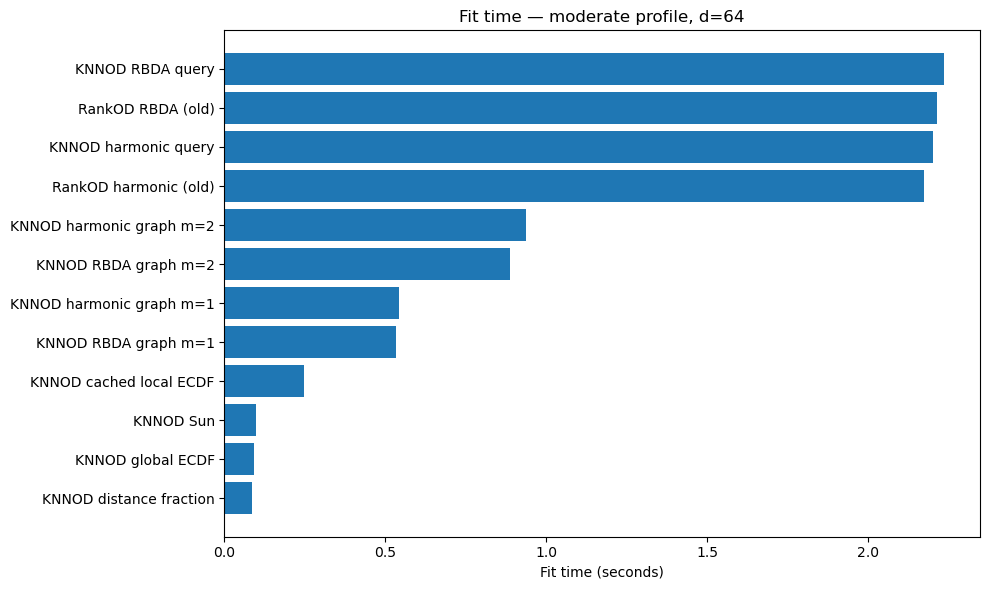

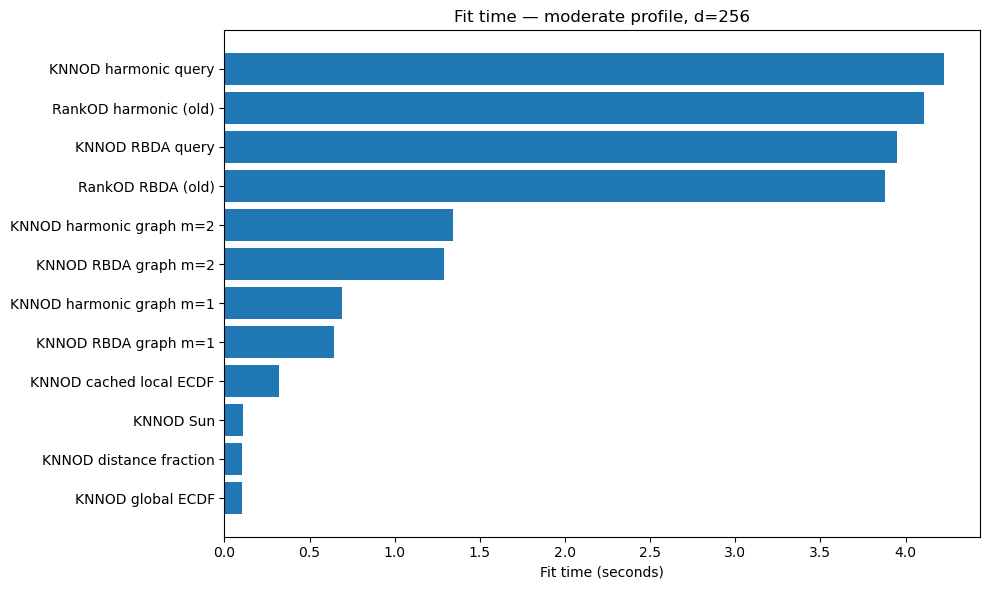

In [12]:
for n_features in FEATURE_DIMENSIONS:
    plot_data = results[results["n_features"] == n_features].sort_values("fit_s")
    plt.figure(figsize=(10, 6))
    plt.barh(plot_data["name"], plot_data["fit_s"])
    plt.xlabel("Fit time (seconds)")
    plt.ylabel("")
    plt.title(f"Fit time — {PROFILE} profile, d={n_features}")
    plt.tight_layout()
    plt.show()


## Steady query-time plots


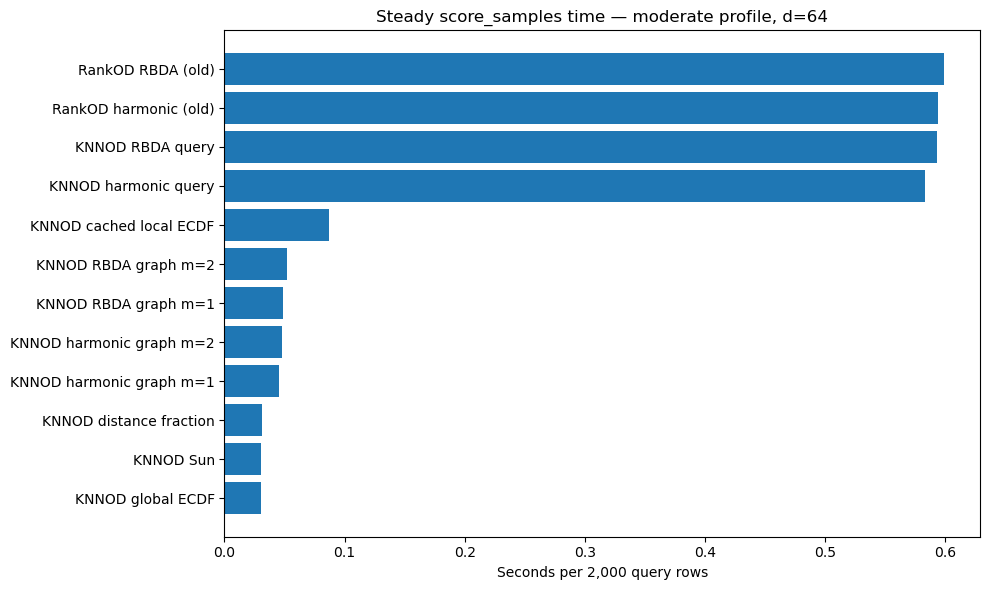

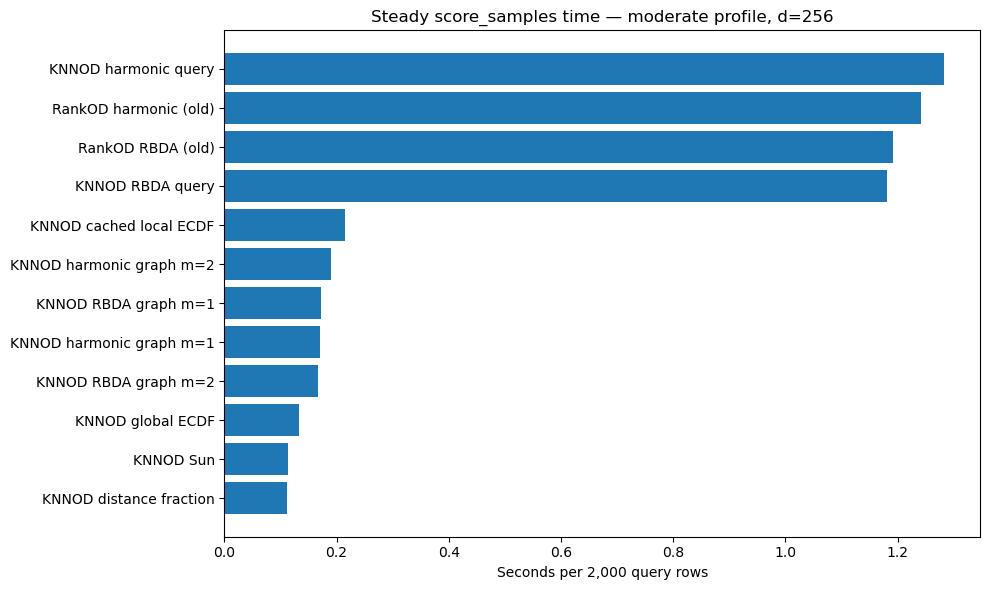

In [13]:
for n_features in FEATURE_DIMENSIONS:
    plot_data = results[results["n_features"] == n_features].sort_values(
        "steady_query_s"
    )
    plt.figure(figsize=(10, 6))
    plt.barh(plot_data["name"], plot_data["steady_query_s"])
    plt.xlabel(f"Seconds per {N_QUERY:,} query rows")
    plt.ylabel("")
    plt.title(f"Steady score_samples time — {PROFILE} profile, d={n_features}")
    plt.tight_layout()
    plt.show()


## Reading the results

- First inspect the ANN-parameter parity table. A matched comparison is valid only when `effective_k == k`, `effective_max_rank == max_rank`, and both implementations report the same backend query epsilon.
- `KNNOD ... query` is the closest compatibility comparison with legacy `RankOD`: it uses the same two-query structure and leaves epsilon at the backend default.
- Remaining disagreement can come from separate PyNNDescent fits, robust self-index removal, invalid-candidate filtering, and the explicit `J + 1` overflow convention. It should not be attributed to a different epsilon or a silently reduced score definition.
- Compare graph `m=1` and `m=2` against the query path. Improvement at `m=2` indicates that fitted-graph neighbour recall is responsible for part of the disagreement.
- The graph path is expected to score much faster because it avoids querying reference rows during every `score_samples` call.
- Report first-query and steady-query latency separately; deferred PyNNDescent preparation can dominate the first call.
- Compare the 64- and 256-dimensional tables independently. Approximate-neighbour recall can degrade as dimension increases, so agreement need not be dimension invariant.
- `graph_width` records the actual fitted index width and makes the memory/fit-time cost of the multiplier visible.